# Modeling and Evaluation

In [2]:
# Library Imports.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Allows plots to appear directly in the notebook.
%matplotlib inline

from patsy import dmatrices
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score

In [3]:
# Reading from a csv file, into a data frame
df = pd.read_csv('ppr-group-25204989-train-Formodeling.csv', keep_default_na=True, delimiter=',', skipinitialspace=True)
# Show data frame first few rows
df.head(10)

,Price(€),NotFullMarketPrice,VATExclusive,DescriptionofProperty,log_price,SaleYear,SaleMonthIndex,Region_Encoded
0,62500.0,0,0,0,11.042938,2016,7,11.664168
1,150000.0,1,0,0,11.918397,2016,12,12.000151
2,94000.0,0,0,0,11.451061,2016,8,11.664168
3,149500.0,0,1,1,11.915058,2016,2,11.056811
4,170000.0,0,0,0,12.043560,2016,10,11.290023
5,50000.0,0,0,0,10.819798,2016,12,11.821056
6,160000.0,0,0,0,11.982935,2016,12,12.288558
7,15000.0,0,0,0,9.615872,2016,10,13.078096
8,160000.0,0,0,0,11.982935,2016,8,11.642599
9,320000.0,0,1,1,12.676079,2016,12,11.886321


In [4]:
df.dtypes

Price(€)                 float64
NotFullMarketPrice         int64
VATExclusive               int64
DescriptionofProperty      int64
log_price                float64
SaleYear                   int64
SaleMonthIndex             int64
Region_Encoded           float64
dtype: object

In [5]:
# Look at correlations for all the continuous features. 
# As SaleYear is kept for grouping, it is excluded. The feature of time is 'SaleMonthIndex'
df[['NotFullMarketPrice', 'VATExclusive', 'DescriptionofProperty','log_price','SaleMonthIndex', 'Region_Encoded']].corr()

,NotFullMarketPrice,VATExclusive,DescriptionofProperty,log_price,SaleMonthIndex,Region_Encoded
NotFullMarketPrice,1.000000,0.015873,0.017724,-0.152229,0.023280,-0.011225
VATExclusive,0.015873,1.000000,0.990553,0.169380,0.041120,0.136927
DescriptionofProperty,0.017724,0.990553,1.000000,0.165843,0.040821,0.135903
log_price,-0.152229,0.169380,0.165843,1.000000,0.241026,0.603799
SaleMonthIndex,0.023280,0.041120,0.040821,0.241026,1.000000,0.365413
Region_Encoded,-0.011225,0.136927,0.135903,0.603799,0.365413,1.000000


### Notice:
The correlation table shows a problem: the correlation between VATExclusive and DescriptionofProperty is as high as 0.99, indicating that these two features are nearly identical in the information they provide to the model. In the Irish property dataset, both fields essentially act as indicators for whether a property is a "New Build" (Subject to VAT) or "Second-hand". So in the medoling section, we decide to keep VATExclusive and drop DescriptionofProperty to remove the redundant feature to simplify the model and prevent the reduction of feature importance.

<Axes: xlabel='Region_Encoded', ylabel='log_price'>

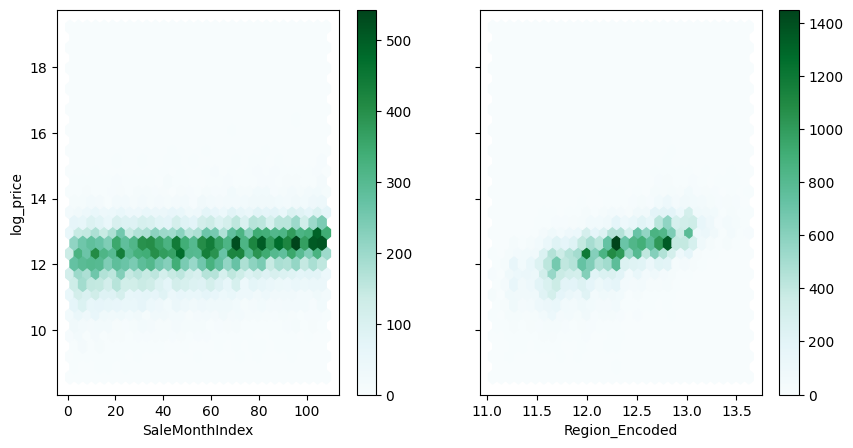

In [6]:
# As the number of samples is huge, it looks messy if we use scatter. So here we use hexbin plot to show the correlation for each continuous descriptive feature and target feature. 
fig, axs = plt.subplots(1, 2, sharey=True)
df.plot(kind='hexbin', x='SaleMonthIndex', y='log_price', gridsize=30,label="%.3f" %df[['SaleMonthIndex', 'Price(€)']].corr().to_numpy()[0,1], ax=axs[0], figsize=(10, 5))
df.plot(kind='hexbin', x='Region_Encoded', y='log_price', gridsize=30,label="%.3f" %df[['Region_Encoded', 'Price(€)']].corr().to_numpy()[0,1], ax=axs[1])

The color shows the density in the area. And the hexbin plots show that both SaleMonthIndex and Region_Encoded have a roughly linear relationship with Price.

## Preparing the data with temporal split.
As price is time related, we split the training data into 5 groups of training dataset and validation dataset by year.<br>
The first group: 2016-2019 for training, 2020 for validation.<br>
The second group: 2017-2020 for training, 2021 for validation.<br>
The third group: 2018-2021 for training, 2022 for validation.<br>
The fourth group: 2019-2022 for training, 2023 for validation.<br>
The fifth group: 2020-2023 for training, 2024 for validation.

In [7]:
# Define descriptive features and target feature
features = ['NotFullMarketPrice', 'VATExclusive', 'SaleMonthIndex', 'Region_Encoded']
target_original = 'Price(€)'
target_log='log_price'


folds = []

# Define start_year, end_year and val_year (year for validation) of each group
group_configs = [
    (2016, 2019, 2020),
    (2017, 2020, 2021),
    (2018, 2021, 2022),
    (2019, 2022, 2023),
    (2020, 2023, 2024)
]

# start grouping
for i, (start_year, end_year, val_year) in enumerate(group_configs):
    # 1. pick out the samples of training data
    train_mask = (df['SaleYear'] >= start_year) & (df['SaleYear'] <= end_year)
    X_train = df.loc[train_mask, features]
    y_train_log = df.loc[train_mask, target_log]
    y_train_original=df.loc[train_mask, target_original]
    
    # 2. pick out the samples of validation data
    val_mask = df['SaleYear'] == val_year
    X_val = df.loc[val_mask, features]
    y_val_original = df.loc[val_mask, target_original]
    y_val_log = df.loc[val_mask, target_log]
    
    # 3. save the data set as dictionary and add into folds
    folds.append({
        'X_train': X_train,
        'y_train_log': y_train_log,
        'y_train_original': y_train_original,
        'X_val': X_val,
        'y_val_log': y_val_log,
        'y_val_original': y_val_original,
        'info': f"Group {i+1}: Train({start_year}-{end_year}) -> Val({val_year})"
    })
    
    print(f" {folds[i]['info']} | training data: {len(X_train)}, validation data: {len(X_val)}")

print("\nDone! Visiting the first group by folds[0]['X_train']")

 Group 1: Train(2016-2019) -> Val(2020) | training data: 23997, validation data: 6000
 Group 2: Train(2017-2020) -> Val(2021) | training data: 23998, validation data: 6000
 Group 3: Train(2018-2021) -> Val(2022) | training data: 23999, validation data: 6000
 Group 4: Train(2019-2022) -> Val(2023) | training data: 23999, validation data: 6000
 Group 5: Train(2020-2023) -> Val(2024) | training data: 24000, validation data: 5999

Done! Visiting the first group by folds[0]['X_train']


## Start modeling

### 

In [8]:
# This function is used repeatedly to compute, print and return the regression metrics
def getMetrics(testActualVal, predictions):
    mae=metrics.mean_absolute_error(testActualVal, predictions)
    rmse=metrics.mean_squared_error(testActualVal, predictions)**0.5
    r2=metrics.r2_score(testActualVal, predictions)
    print('\n==============================================================================')
    print("MAE: ", mae)
    #print("MSE: ", metrics.mean_squared_error(testActualVal, predictions))
    print("RMSE: ", rmse)
    print("R2: ", r2)
    return (mae,rmse,r2)

In [9]:
# Initialize variables for recording evaluation results
features = ['NotFullMarketPrice', 'VATExclusive', 'SaleMonthIndex', 'Region_Encoded']
results=[]

In [10]:
# get baseline data
print('Baseline')

y=df[['Price(€)']]
baseline_pred = np.full(shape=y.shape[0], fill_value=y.mean())
(mae,rmse,r2)=getMetrics(y,baseline_pred)
results.append({
    'model':'Baseline',
    'MAE':mae,
    'RMSE':rmse,
    'R2':r2
})

Baseline

MAE:  194184.57136897265
RMSE:  1391583.1506862247
R2:  0.0


### 1 Modeling with LinearRegression

In [ ]:
from sklearn.linear_model import LinearRegression

print("Linear Regression")
errors = {
    'MAE': [],
    'RMSE': [],
    'R2': []
}

for fold in folds:
    print('=' * 70)
    print(fold['info'])

    # Prep data
    X_train = fold['X_train']
    y_train_log = fold['y_train_log']
    y_train_original = fold['y_train_original']

    X_val = fold['X_val']
    y_val_original = fold['y_val_original']

    # Train with linear regression model
    linreg = LinearRegression()
    linreg.fit(X_train, y_train_log)

    # Print the weights learned for each feature
    print("\nIntercept:\n", linreg.intercept_)
    print("Features and coefficients:", list(zip(features, linreg.coef_))[:10])

    # Predicted price on validation set
    pred_log = linreg.predict(X_val)
    pred_original = np.expm1(pred_log)
    
    (mae, rmse, r2) = getMetrics(y_val_original, pred_original)
    errors['MAE'].append(mae)
    errors['RMSE'].append(rmse)
    errors['R2'].append(r2)

    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': features,
        'importance': linreg.coef_
    })
    display(feature_importance.sort_values('importance', ascending=False)) 

# Print performance metrics
print('MAE:', errors['MAE'])
print('RMSE:', errors['RMSE'])
print('R2:', errors['R2'])

# Calculate average performance metrics
mean_mae = sum(errors['MAE']) / len(errors['MAE'])
mean_rmse = sum(errors['RMSE']) / len(errors['RMSE'])
mean_r2 = sum(errors['R2']) / len(errors['R2'])
results.append({
    'model':'Linear Regression',
    'MAE':mean_mae,
    'RMSE':mean_rmse,
    'R2':mean_r2
})
print("\nAverage Performance of Linear Regression:")
print(results[-1])

Linear Regression
Group 1: Train(2016-2019) -> Val(2020)

Intercept:
 0.8181531897703369
Features and coefficients: [('NotFullMarketPrice', np.float64(-0.48379512597746943)), ('VATExclusive', np.float64(0.13742892370293733)), ('SaleMonthIndex', np.float64(0.0019789705177705157)), ('Region_Encoded', np.float64(0.9336237361892471))]

MAE:  128027.94524629023
RMSE:  501339.6339425395
R2:  0.06691189414953902


,feature,importance
3,Region_Encoded,0.933624
1,VATExclusive,0.137429
2,SaleMonthIndex,0.001979
0,NotFullMarketPrice,-0.483795


Group 2: Train(2017-2020) -> Val(2021)

Intercept:
 1.167138164356441
Features and coefficients: [('NotFullMarketPrice', np.float64(-0.4890991910570601)), ('VATExclusive', np.float64(0.1735613480202956)), ('SaleMonthIndex', np.float64(-0.0010286196748488183)), ('Region_Encoded', np.float64(0.9126917771038122))]

MAE:  151829.21152643347
RMSE:  991405.1753459485
R2:  0.01733518274106083


,feature,importance
3,Region_Encoded,0.912692
1,VATExclusive,0.173561
2,SaleMonthIndex,-0.001029
0,NotFullMarketPrice,-0.489099


Group 3: Train(2018-2021) -> Val(2022)

Intercept:
 1.1042487172630455
Features and coefficients: [('NotFullMarketPrice', np.float64(-0.538420548289847)), ('VATExclusive', np.float64(0.19579019496856653)), ('SaleMonthIndex', np.float64(0.0007832642027511585)), ('Region_Encoded', np.float64(0.9114401817038144))]

MAE:  146557.50739254063
RMSE:  409659.40088380716
R2:  0.09708809870715285


...

Group 4: Train(2019-2022) -> Val(2023)

Intercept:
 0.9033637112674455
Features and coefficients: [('NotFullMarketPrice', np.float64(-0.54514399070456)), ('VATExclusive', np.float64(0.20706219772000145)), ('SaleMonthIndex', np.float64(0.0025169216822235217)), ('Region_Encoded', np.float64(0.9193456554053896))]

MAE:  171436.5368485647
RMSE:  1289790.4776352006
R2:  0.015727774573435882


,feature,importance
3,Region_Encoded,0.919346
1,VATExclusive,0.207062
2,SaleMonthIndex,0.002517
0,NotFullMarketPrice,-0.545144


Group 5: Train(2020-2023) -> Val(2024)

Intercept:
 1.0763647079362038
Features and coefficients: [('NotFullMarketPrice', np.float64(-0.5626443381807652)), ('VATExclusive', np.float64(0.21590397623084834)), ('SaleMonthIndex', np.float64(0.0013401784895649403)), ('Region_Encoded', np.float64(0.9098789528797256))]

MAE:  205041.28516715026
RMSE:  2935018.7147198776
R2:  0.004133771623567317


,feature,importance
3,Region_Encoded,0.909879
1,VATExclusive,0.215904
2,SaleMonthIndex,0.001340
0,NotFullMarketPrice,-0.562644


MAE: [128027.94524629023, 151829.21152643347, 146557.50739254063, 171436.5368485647, 205041.28516715026]
RMSE: [501339.6339425395, 991405.1753459485, 409659.40088380716, 1289790.4776352006, 2935018.7147198776]
R2: [0.06691189414953902, 0.01733518274106083, 0.09708809870715285, 0.015727774573435882, 0.004133771623567317]

Average Performance of Linear Regression:
{'model': 'Linear Regression', 'MAE': 160578.49723619586, 'RMSE': 1225442.6805054746, 'R2': 0.04023934435895118}


The Linear Regression model shows relatively poor performance. The average MAE of 160,578 suggests a significant deviation from the true property prices. Similarly, the average RMSE of 1,225,443 indicates potential large prediction errors. Moreover, R2 records an extremely low score of 0.04, meaning the model can only explain 4% of the variance in property price. In summary, the Linear Regression model cannot fully capture the relationship between features and the target, showing a clear sign of underfitting. Potential reasons for this might be the model’s inability to capture non-linear relationships in the dataset, and the limited set of input features used.

### 2 Modeling with Lasso

In [29]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

print("Lasso")

errors = {
    'MAE': [],
    'RMSE': [],
    'R2': []
}

for fold in folds:
    print('=' * 70)
    print(fold['info'])

    # Prep data
    X_train = fold['X_train']
    y_train_log = fold['y_train_log']
    y_train_original = fold['y_train_original']

    X_val = fold['X_val']
    y_val_original = fold['y_val_original']

    # Standardise numeric features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # Train with Lasso model
    lasso = Lasso(alpha=0.001) 
    lasso.fit(X_train_scaled, y_train_log)
    
    # Print the weights learned for each feature
    print("\nIntercept:\n", lasso.intercept_)
    print("Features and coefficients:", list(zip(features, lasso.coef_))[:10])

    # Predicted price on validation set
    pred_log = lasso.predict(X_val_scaled)
    pred_original = np.expm1(pred_log)

    (mae, rmse, r2) = getMetrics(y_val_original, pred_original)
    errors['MAE'].append(mae)
    errors['RMSE'].append(rmse)
    errors['R2'].append(r2)

    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': features,
        'importance': lasso.coef_
    })
    display(feature_importance.sort_values('importance', ascending=False)) 

# Print performance metrics
print('MAE:', errors['MAE'])
print('RMSE:', errors['RMSE'])
print('R2:', errors['R2'])

# Calculate average performance metrics
mean_mae = sum(errors['MAE']) / len(errors['MAE'])
mean_rmse = sum(errors['RMSE']) / len(errors['RMSE'])
mean_r2 = sum(errors['R2']) / len(errors['R2'])
results.append({
    'model':'Lasso',
    'MAE':mean_mae,
    'RMSE':mean_rmse,
    'R2':mean_r2
})
print("\nAverage Performance of Lasso:")
print(results[-1])

Lasso
Group 1: Train(2016-2019) -> Val(2020)

Intercept:
 12.192162831250512
Features and coefficients: [('NotFullMarketPrice', np.float64(-0.10458652068554182)), ('VATExclusive', np.float64(0.050918984903585006)), ('SaleMonthIndex', np.float64(0.026448125109238076)), ('Region_Encoded', np.float64(0.46909714923205803))]

MAE:  127910.89365606531
RMSE:  501424.60302933474
R2:  0.06659558018773304


,feature,importance
3,Region_Encoded,0.469097
1,VATExclusive,0.050919
2,SaleMonthIndex,0.026448
0,NotFullMarketPrice,-0.104587


Group 2: Train(2017-2020) -> Val(2021)

Intercept:
 12.263928427921055
Features and coefficients: [('NotFullMarketPrice', np.float64(-0.10946017183440461)), ('VATExclusive', np.float64(0.06662743789227384)), ('SaleMonthIndex', np.float64(-0.01311954936881298)), ('Region_Encoded', np.float64(0.44346809910450824))]

MAE:  151761.05781218733
RMSE:  991370.7538936138
R2:  0.0174034175330795


,feature,importance
3,Region_Encoded,0.443468
1,VATExclusive,0.066627
2,SaleMonthIndex,-0.013120
0,NotFullMarketPrice,-0.109460


Group 3: Train(2018-2021) -> Val(2022)

Intercept:
 12.32051972327395
Features and coefficients: [('NotFullMarketPrice', np.float64(-0.12038781532689014)), ('VATExclusive', np.float64(0.07522827060639962)), ('SaleMonthIndex', np.float64(0.009954750566700166)), ('Region_Encoded', np.float64(0.4180384421060743))]

MAE:  146533.3375347299
RMSE:  409830.35298310244
R2:  0.09633436577189691


...

Group 4: Train(2019-2022) -> Val(2023)

Intercept:
 12.390605512971758
Features and coefficients: [('NotFullMarketPrice', np.float64(-0.1199549637670788)), ('VATExclusive', np.float64(0.07840923251048815)), ('SaleMonthIndex', np.float64(0.03386728194946271)), ('Region_Encoded', np.float64(0.4027560268448521))]

MAE:  171162.7441637637
RMSE:  1289846.2933065097
R2:  0.01564258398677465


,feature,importance
3,Region_Encoded,0.402756
1,VATExclusive,0.078409
2,SaleMonthIndex,0.033867
0,NotFullMarketPrice,-0.119955


Group 5: Train(2020-2023) -> Val(2024)

Intercept:
 12.45593814724864
Features and coefficients: [('NotFullMarketPrice', np.float64(-0.12333148871608654)), ('VATExclusive', np.float64(0.0819870157266874)), ('SaleMonthIndex', np.float64(0.017569450797812202)), ('Region_Encoded', np.float64(0.390062407957286))]

MAE:  204850.9420915225
RMSE:  2935086.916798195
R2:  0.004087488487243274


,feature,importance
3,Region_Encoded,0.390062
1,VATExclusive,0.081987
2,SaleMonthIndex,0.017569
0,NotFullMarketPrice,-0.123331


MAE: [127910.89365606531, 151761.05781218733, 146533.3375347299, 171162.7441637637, 204850.9420915225]
RMSE: [501424.60302933474, 991370.7538936138, 409830.35298310244, 1289846.2933065097, 2935086.916798195]
R2: [0.06659558018773304, 0.0174034175330795, 0.09633436577189691, 0.01564258398677465, 0.004087488487243274]

Average Performance of Lasso:
{'model': 'Lasso', 'MAE': 160443.79505165375, 'RMSE': 1225511.784002151, 'R2': 0.04001268719334548}


Lasso model also shows poor predictive performance. The average MAE of 160,444 and average RMSE of 1,225,512 report prediction errors. Moreover, R2 remains a low score of around 0.04, meaning the model explains only a small proportion of the variance in the target variable. Overall, Lasso model is still underfitting the data. This is likely due to the simplicity of the model and lack of sufficient relevant features. 

### 3 Modeling with RidgeCV

In [24]:
from sklearn.linear_model import RidgeCV
print("Ridge")
errors={
    'MAE':[],
    'RMSE':[],
    'R2':[]
    }
for fold in folds:
    # print the info of current group
    print('='*70)
    print(fold['info'])

    # pick out the dataset
    X_train=fold['X_train']
    y_train_log=fold['y_train_log']
    y_train_original=fold['y_train_original']
    X_val=fold['X_val']
    y_val_log=fold['y_val_log']
    y_val_original=fold['y_val_original']

    # train the model
    ridge = RidgeCV()
    ridge.fit(X_train, y_train_log)

    # Print the weights learned for each feature.
    print("\nIntercept: \n", ridge.intercept_)
    print("Features and coeficients:", list(zip(features, ridge.coef_))[:10])
  
    # Predicted price on validation set
    pred_log = ridge.predict(X_val)
    pred_original=np.expm1(pred_log)
    (mae,rmse,r2)=getMetrics(y_val_original, pred_original)
    errors['MAE'].append(mae)
    errors['RMSE'].append(rmse)
    errors['R2'].append(r2)

    feature_importance = pd.DataFrame({'feature': features, 'importance':ridge.coef_})
    display(feature_importance.sort_values('importance', ascending=False))

Ridge
Group 1: Train(2016-2019) -> Val(2020)

Intercept: 
 0.8199804464165279
Features and coeficients: [('NotFullMarketPrice', np.float64(-0.48337795035007325)), ('VATExclusive', np.float64(0.13742076452998475)), ('SaleMonthIndex', np.float64(0.001979595467105355)), ('Region_Encoded', np.float64(0.9334702001180233))]

MAE:  128024.17823648283
RMSE:  501341.50505528506
R2:  0.06690492914542834


,feature,importance
3,Region_Encoded,0.933470
1,VATExclusive,0.137421
2,SaleMonthIndex,0.001980
0,NotFullMarketPrice,-0.483378


Group 2: Train(2017-2020) -> Val(2021)

Intercept: 
 1.1690242178846653
Features and coeficients: [('NotFullMarketPrice', np.float64(-0.48870738616580667)), ('VATExclusive', np.float64(0.17354342311022286)), ('SaleMonthIndex', np.float64(-0.0010276956676307236)), ('Region_Encoded', np.float64(0.9125328330568436))]

MAE:  151829.82760557186
RMSE:  991407.5943682196
R2:  0.017330387343503673


,feature,importance
3,Region_Encoded,0.912533
1,VATExclusive,0.173543
2,SaleMonthIndex,-0.001028
0,NotFullMarketPrice,-0.488707


Group 3: Train(2018-2021) -> Val(2022)

Intercept: 
 1.1063094239367306
Features and coeficients: [('NotFullMarketPrice', np.float64(-0.5379870842117391)), ('VATExclusive', np.float64(0.19575992610412563)), ('SaleMonthIndex', np.float64(0.000783963300762025)), ('Region_Encoded', np.float64(0.9112677991384981))]

MAE:  146554.92982641744
RMSE:  409664.0391094228
R2:  0.09706765278154594


,feature,importance
3,Region_Encoded,0.911268
1,VATExclusive,0.195760
2,SaleMonthIndex,0.000784
0,NotFullMarketPrice,-0.537987


Group 4: Train(2019-2022) -> Val(2023)

Intercept: 
 0.9056592599084183
Features and coeficients: [('NotFullMarketPrice', np.float64(-0.5446887801205609)), ('VATExclusive', np.float64(0.20702405084841757)), ('SaleMonthIndex', np.float64(0.002517771636632915)), ('Region_Encoded', np.float64(0.919153726991901))]

MAE:  171428.3827560667
RMSE:  1289792.2320502044
R2:  0.015725096893356105


,feature,importance
3,Region_Encoded,0.919154
1,VATExclusive,0.207024
2,SaleMonthIndex,0.002518
0,NotFullMarketPrice,-0.544689


Group 5: Train(2020-2023) -> Val(2024)

Intercept: 
 1.0787850047598049
Features and coeficients: [('NotFullMarketPrice', np.float64(-0.5621726040012871)), ('VATExclusive', np.float64(0.21586142992492796)), ('SaleMonthIndex', np.float64(0.0013414544932004446)), ('Region_Encoded', np.float64(0.9096747164538153))]

MAE:  205034.02783341875
RMSE:  2935020.5279863398
R2:  0.0041325411227998154


,feature,importance
3,Region_Encoded,0.909675
1,VATExclusive,0.215861
2,SaleMonthIndex,0.001341
0,NotFullMarketPrice,-0.562173


Intercept is the base value. Importance (coeficients)  of features means how much the feature contributes to the prediction. Take group 5 as an example:<br>

price=-58603.03464235173+36938.314172\*VATExclusive+246.619944\*SaleMonthIndex+1.195068\*Region_Encoded+-105837.143803\*NotFullMarketPrice<br>

1,VATExclusive:36938.314172. It means if the property is VATExclusive, it adds €36938.314172 to the base value.<br>

2,SaleMonthIndex: 246.619944. It means the price grows by €246.619944 by month.<br>

3,Region_Encoded: 1.195068. It means adding 1.195068 times of the Region_Encoded value (the average price of the region in last year) to the base value.<br>

4,NotFullMarketPrice:-105837.143803. It means if the property is NotFullMarketPrice, the price declines by €105837.143803<br>

In [12]:
print('MAE:',errors['MAE'])
print('RMSE:',errors['RMSE'])
print('R2:',errors['R2'])

mean_mae=sum(errors['MAE'])/len(errors['MAE'])
mean_rmse=sum(errors['RMSE'])/len(errors['RMSE'])
mean_r2=sum(errors['R2'])/len(errors['R2'])
results.append({
    'model':'RidgeCV',
    'MAE':mean_mae,
    'RMSE':mean_rmse,
    'R2':mean_r2
})
print(results[-1])

MAE: [128024.17823648283, 151829.82760557186, 146554.92982641744, 171428.3827560667, 205034.02783341875]
RMSE: [501341.50505528506, 991407.5943682196, 409664.0391094228, 1289792.2320502044, 2935020.5279863398]
R2: [0.06690492914542834, 0.017330387343503673, 0.09706765278154594, 0.015725096893356105, 0.0041325411227998154]
{'model': 'RidgeCV', 'MAE': 160574.26925159153, 'RMSE': 1225445.1797138944, 'R2': 0.040232121457326776}


The performance of the model keeps stable on different groups . An average R2 of 0.04 means the model does not predict well, just similar to predicting with average.

### 4 Modeling with Random Forest

In [15]:
from sklearn.ensemble import RandomForestRegressor

print("Random Forest")

# Store evaluation results for each fold
errors = {
    'MAE': [],
    'RMSE': [],
    'R2': []
}

# Store feature importance from each fold
rf_feature_importances = []

# Loop through each time-based fold
for fold in folds:
    print('=' * 70)
    print(fold['info'])

    # Get training and validation data for this fold
    X_train = fold['X_train']
    y_train_log = fold['y_train_log']
    X_val = fold['X_val']
    y_val_original = fold['y_val_original']

    # Build Random Forest model
    # n_estimators: number of trees
    # max_depth: maximum depth of each tree
    # min_samples_split / min_samples_leaf: help reduce overfitting
    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    # Train model using log-transformed target
    rf_model.fit(X_train, y_train_log)

    # Predict log_price on validation set
    pred_log = rf_model.predict(X_val)

    # Convert predicted log_price back to original price
    # Use expm1 because log_price was likely created by np.log1p(price)
    pred_original = np.expm1(pred_log)

    # Evaluate predictions against original price
    mae, rmse, r2 = getMetrics(y_val_original, pred_original)

    # Save fold metrics
    errors['MAE'].append(mae)
    errors['RMSE'].append(rmse)
    errors['R2'].append(r2)

    # Save feature importance for this fold
    rf_feature_importances.append(rf_model.feature_importances_)

# Print metrics from all folds
print('MAE:', errors['MAE'])
print('RMSE:', errors['RMSE'])
print('R2:', errors['R2'])

# Calculate average metrics across all folds
mean_mae = sum(errors['MAE']) / len(errors['MAE'])
mean_rmse = sum(errors['RMSE']) / len(errors['RMSE'])
mean_r2 = sum(errors['R2']) / len(errors['R2'])

# Save final averaged result into results list
results.append({
    'model': 'Random Forest',
    'MAE': mean_mae,
    'RMSE': mean_rmse,
    'R2': mean_r2
})

print("\nAverage Random Forest Performance:")
print(results[-1])

# Calculate average feature importance across all folds
mean_importance = np.mean(rf_feature_importances, axis=0)

rf_importance_df = pd.DataFrame({
    'feature': features,
    'importance': mean_importance
}).sort_values('importance', ascending=False)

print("\nAverage Feature Importance (Random Forest):")
display(rf_importance_df)

Random Forest
Group 1: Train(2016-2019) -> Val(2020)

MAE:  130121.96284730427
RMSE:  505224.9754912798
R2:  0.05239313725803063
Group 2: Train(2017-2020) -> Val(2021)

MAE:  156248.18292718253
RMSE:  993893.0681683844
R2:  0.01239707604618201
Group 3: Train(2018-2021) -> Val(2022)

MAE:  149936.18124874565
RMSE:  412666.46007751033
R2:  0.0837840001924618
Group 4: Train(2019-2022) -> Val(2023)

MAE:  175040.5667498223
RMSE:  1289486.4183317781
R2:  0.016191790793371963
Group 5: Train(2020-2023) -> Val(2024)

MAE:  204895.22524142353
RMSE:  2938092.3478281386
R2:  0.0020468819286750817
MAE: [130121.96284730427, 156248.18292718253, 149936.18124874565, 175040.5667498223, 204895.22524142353]
RMSE: [505224.9754912798, 993893.0681683844, 412666.46007751033, 1289486.4183317781, 2938092.3478281386]
R2: [0.05239313725803063, 0.01239707604618201, 0.0837840001924618, 0.016191790793371963, 0.0020468819286750817]

Average Random Forest Performance:
{'model': 'Random Forest', 'MAE': 163248.42380289

,feature,importance
3,Region_Encoded,0.822848
2,SaleMonthIndex,0.078706
0,NotFullMarketPrice,0.061003
1,VATExclusive,0.037443


The Random Forest model achieved very poor performance, with an R² score of approximately 0.03, indicating that it explains only a small fraction of the variance in house prices.

The MAE and RMSE values are also very high, suggesting large prediction errors and poor generalisation.

This is likely due to the limited set of input features used in the model. The current features do not sufficiently capture important factors affecting house prices, such as detailed location, property characteristics, or structural attributes.

As a result, the model relies heavily on a single feature (Region_Encoded), leading to weak predictive performance

### 5 Modeling with Pipeline

In [ ]:
#code here